# Notebook Training Summarization

Extractive :
- Textrank
- NER

Abstractive
- IndoBART = indobenchmark/indoBART
- mT5-base = google/mt5-base
- IndoT5 = cahya/t5-base-indonesian-summarization-cased

In [1]:
import sys, importlib, subprocess

PACKAGES = {
    "transformers"   : "transformers==4.40.0",
    "datasets"       : "datasets",
    "accelerate"     : "accelerate",
    "sentencepiece"  : "sentencepiece",
    "tokenizers"     : "tokenizers",
    "google.protobuf": "protobuf",
    "pandas"         : "pandas",
    "pyarrow"        : "pyarrow",
    "numpy"          : "numpy",
    "matplotlib"     : "matplotlib",
    "rouge_score"    : "rouge-score",
    "sklearn"        : "scikit-learn",
    "networkx"       : "networkx",
    "PySastrawi"     : "PySastrawi",
    "indobenchmark"  : "indobenchmark-toolkit",  # IndoNLGTokenizer for IndoBART
}

to_install = []
for module, pkg in PACKAGES.items():
    try:
        importlib.import_module(module)
        print(f"  [ok]      {pkg}")
    except ImportError:
        print(f"  [missing] {pkg}")
        to_install.append(pkg)

if to_install:
    print(f"\nInstalling {len(to_install)} package(s)...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q"] + to_install,
        check=True,
    )
    print("Selesai. Lanjutkan run ke bawah.")
else:
    print("\nSemua package sudah terinstall.")

  [ok]      transformers==4.40.0
  [ok]      datasets
  [ok]      accelerate
  [ok]      sentencepiece
  [ok]      tokenizers
  [ok]      protobuf
  [ok]      pandas
  [ok]      pyarrow
  [ok]      numpy
  [ok]      matplotlib
  [ok]      rouge-score
  [ok]      scikit-learn
  [ok]      networkx
  [missing] PySastrawi
  [ok]      indobenchmark-toolkit

Installing 1 package(s)...
Selesai. Lanjutkan run ke bawah.


In [2]:
import sys
print(sys.executable)
print(sys.version)

import pandas as pd
import pyarrow
import transformers
import datasets

print("All basic libraries OK")
print("Pandas:", pd.__version__)
print("Transformers:", transformers.__version__)

/venv/main/bin/python
3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:50:00) [GCC 14.3.0]
All basic libraries OK
Pandas: 3.0.3
Transformers: 4.40.0


# Setup Env & Global Var Parameter

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]   = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc, re, json, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer,
    EarlyStoppingCallback,
)
from datasets import Dataset

DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
USE_BF16 = torch.cuda.is_bf16_supported() if DEVICE == "cuda" else False
USE_FP16 = False

assert DEVICE == "cuda", "Notebook ini butuh GPU. Jalankan di vast.ai dengan RTX 3090/4090."
print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB  |  bf16: {USE_BF16}")
print(f"torch: {torch.__version__}")


GPU  : NVIDIA GeForce RTX 3090
VRAM : 25.3 GB  |  bf16: True
torch: 2.11.0+cu130


In [ ]:
# Model checkpoints
INDOT5_MODEL   = "cahya/t5-base-indonesian-summarization-cased"
INDOBART_MODEL = "indobenchmark/indoBART"
MT5BASE_MODEL  = "google/mt5-base"

# Hyperparameter global
SUMM_MAX_INPUT      = 512    # panjang maksimum input ke tokenizer
SUMM_MAX_TARGET     = 150    # panjang maksimum summary yang digenerate
SUMM_LR             = 5e-5   # KRITIS: NaN crash di mT5 jika lebih tinggi dari ini
SUMM_EPOCHS         = 3      # 3 epoch cukup untuk 10K data; lebih cenderung overfit
SUMM_BATCH          = 8      # per-GPU batch size saat training
SUMM_EVAL_BATCH     = 4      # per-GPU batch size saat eval (lebih kecil, hemat VRAM)
SUMM_GRAD_ACCUM     = 2      # eff. batch = SUMM_BATCH * SUMM_GRAD_ACCUM = 16
SUMM_MAX_GRAD_NORM  = 1.0    # gradient clipping, cegah exploding gradient
LABEL_SMOOTHING     = 0.1    # regularisasi distribusi output untuk seq2seq
WARMUP_RATIO        = 0.1    # 10% step pertama sebagai linear warmup
WEIGHT_DECAY        = 0.01   # L2 regularisasi pada weight (kecuali bias dan LayerNorm)
EARLY_STOP_PATIENCE = 2      # hentikan jika eval_loss tidak membaik selama 2 epoch
EVAL_ACCUM_STEPS    = 4      # akumulasi langkah saat eval agar tidak OOM
RANDOM_SEED         = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"LR={SUMM_LR}  batch={SUMM_BATCH}  eff_batch={SUMM_BATCH * SUMM_GRAD_ACCUM}")
print(f"bf16={USE_BF16}  label_smoothing={LABEL_SMOOTHING}  early_stop_patience={EARLY_STOP_PATIENCE}")


LR=5e-05  batch=8  eff_batch=16
bf16=True  label_smoothing=0.1  early_stop_patience=2


# Path Configuraiton

In [5]:
CWD = Path.cwd()
ROOT       = CWD if (CWD / "data").exists() else CWD.parent
DATA_DIR   = ROOT / "data"
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

GEN_KWARGS = dict(
    max_new_tokens       = SUMM_MAX_TARGET,  # panjang ringkasan yang digenerate
    num_beams            = 4,                # beam search: pertimbangkan 4 kandidat per step
    no_repeat_ngram_size = 3,                # cegah pengulangan frasa 3 kata berturut
    early_stopping       = True,             # berhenti saat semua beam mencapai EOS
    length_penalty       = 1.0,              # 1.0 = netral terhadap panjang output
)

print(f"DATA_DIR  : {DATA_DIR}")
print(f"MODELS_DIR: {MODELS_DIR}")
print(f"GEN_KWARGS: {GEN_KWARGS}")


DATA_DIR  : /workspace/data
MODELS_DIR: /workspace/models
GEN_KWARGS: {'max_new_tokens': 150, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'early_stopping': True, 'length_penalty': 1.0}


In [ ]:
# Load data Indosum Parquet

df_train = pd.read_parquet(DATA_DIR / "train.parquet")
df_val   = pd.read_parquet(DATA_DIR / "val.parquet")
df_test  = pd.read_parquet(DATA_DIR / "test.parquet")
# df_test tidak disentuh hingga section evaluasi (section 12)

print(f"Train : {len(df_train):,} rows")
print(f"Val   : {len(df_val):,} rows")
print(f"Test  : {len(df_test):,} rows") # ga digunain sampe evaluasi
print(f"\nStats train:")
print(f"  avg word_count        : {df_train['word_count'].mean():.0f}")
print(f"  avg summary_word_count: {df_train['summary_word_count'].mean():.0f}")
print(f"  avg compression_ratio : {df_train['compression_ratio'].mean():.4f}")


Train : 10,000 rows
Val   : 679 rows
Test  : 700 rows

Stats train:
  avg word_count        : 307
  avg summary_word_count: 60
  avg compression_ratio : 0.2244


In [7]:
# Tampilkan 3 contoh artikel dan ringkasannya dari training set
for i in range(3):
    row = df_train.iloc[i]
    print(f"[{i}] Category: {row['category']}  |  Words: {row['word_count']}  |  CR: {row['compression_ratio']:.3f}")
    print(f"  TEXT   : {row['text'][:130]}...")
    print(f"  SUMMARY: {row['summary'][:110]}...")
    print()


[0] Category: olahraga  |  Words: 334  |  CR: 0.186
  TEXT   : Pelatih AC Milan Vincenzo Montella mengatakan klubnya tidak sedang dikejar waktu untuk segera merekrut penyerang baru demi menamba...
  SUMMARY: Pelatih AC Milan Vincenzo Montella mengatakan klubnya tidak sedang dikejar waktu untuk segera merekrut penyera...

[1] Category: olahraga  |  Words: 432  |  CR: 0.141
  TEXT   : Jakarta, CNN Indonesia - - Julukan Mutiara Hitam yang disematkan kepada Persipura Jayapura bukan tanpa makna. Klub asal Papua ters...
  SUMMARY: Julukan Mutiara Hitam yang disematkan kepada Persipura Jayapura bukan tanpa makna. Klub asal Papua tersebut te...

[2] Category: tajuk utama  |  Words: 220  |  CR: 0.268
  TEXT   : Jakarta, CNN Indonesia - - Satuan Reserse Kriminal ( Satreskrim) Polrestabes Bandung berhasil menangkap pelaku pengeroyok Ricko An...
  SUMMARY: Satuan Reserse Kriminal Polrestabes Bandung berhasil menangkap pelaku pengeroyok Ricko Andrean, suporter Persi...



# Preprocessing (Extractive, dan Abstractive)



In [8]:
try:
    from PySastrawi.Stemmer.StemmerFactory import StemmerFactory
except ImportError:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

_stemmer = StemmerFactory().create_stemmer()

STEM_STOPWORDS = {
    "rt","rw","jl","bpbd","dinas","kelurahan","kecamatan","lapor",
    "laporan","pengaduan","warga","masyarakat","pemerintah","kantor",
    "jalan","gedung","sekolah","puskesmas","pasar","sungai","jembatan",
}


def clean_noise(text: str) -> str:
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    return re.sub(r"\s+", " ", text).strip()


def normalize_case_punct(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[!?]{2,}", "!", text)
    return re.sub(r"\s([.,!?;:])", r"\1", text).strip()


def stem_text(text: str) -> str:
    return " ".join(
        w if w.lower() in STEM_STOPWORDS else _stemmer.stem(w)
        for w in text.split()
    )


In [ ]:
def preprocess_extractive(text: str) -> str:
    # Untuk TextRank / NER: clean + normalize + stem
    return stem_text(normalize_case_punct(clean_noise(text)))


def preprocess_abstractive(text: str) -> str:
    # Untuk IndoT5 / IndoBART / mT5-base: clean + normalize SAJA, TANPA stem
    return normalize_case_punct(clean_noise(text))


demo = "Saya melaporkan jalan rusak di RT 05 RW 02!! https://example.com/x  Sudah tiga bulan."
print("RAW        :", demo)
print("EXTRACTIVE :", preprocess_extractive(demo))
print("ABSTRACTIVE:", preprocess_abstractive(demo))

RAW        : Saya melaporkan jalan rusak di RT 05 RW 02!! https://example.com/x  Sudah tiga bulan.
EXTRACTIVE : saya lapor jalan rusak di rt 05 rw 02 sudah tiga bulan
ABSTRACTIVE: saya melaporkan jalan rusak di rt 05 rw 02! sudah tiga bulan.


# Function Training Helpers

In [10]:
def free_vram(*objs):
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [11]:
def build_hf_dataset(df, tokenizer, model_type,
                     max_input=SUMM_MAX_INPUT, max_target=SUMM_MAX_TARGET):
    inputs  = df["text"].apply(preprocess_abstractive).tolist()
    if model_type == "mt5":
        # mT5 perlu prefix task agar tahu harus melakukan summarization
        inputs = ["summarize: " + t for t in inputs]
    targets = df["summary"].astype(str).tolist()

    def tokenize(batch):
        model_inputs = tokenizer(
            batch["input"], max_length=max_input, truncation=True
        )
        # IndoNLGTokenizer mungkin tidak support text_target= kwarg — fallback ke positional
        try:
            labels = tokenizer(
                text_target=batch["target"], max_length=max_target, truncation=True
            )
        except TypeError:
            labels = tokenizer(
                batch["target"], max_length=max_target, truncation=True
            )
        # Ganti pad_token_id dengan -100 agar padding tidak dihitung dalam loss
        pad = tokenizer.pad_token_id
        model_inputs["labels"] = [
            [(t if t != pad else -100) for t in seq]
            for seq in labels["input_ids"]
        ]
        return model_inputs

    ds = Dataset.from_dict({"input": inputs, "target": targets})
    return ds.map(tokenize, batched=True, remove_columns=ds.column_names)

# TRAIN INDOBART

In [ ]:
# Konfigurasi IndoBART
INDOBART_CONFIG = {
    "num_train_epochs"            : SUMM_EPOCHS,
    "per_device_train_batch_size" : SUMM_BATCH,
    "per_device_eval_batch_size"  : SUMM_EVAL_BATCH,
    "gradient_accumulation_steps" : SUMM_GRAD_ACCUM,       # eff. batch = 16
    "learning_rate"               : SUMM_LR,               # 5e-5
    "warmup_ratio"                : WARMUP_RATIO,
    "weight_decay"                : WEIGHT_DECAY,
    "max_grad_norm"               : SUMM_MAX_GRAD_NORM,
    "label_smoothing_factor"      : LABEL_SMOOTHING,
    "bf16"                        : USE_BF16,
    "fp16"                        : False,
    "gradient_checkpointing"      : True,
    "eval_accumulation_steps"     : EVAL_ACCUM_STEPS,
    "early_stopping_patience"     : EARLY_STOP_PATIENCE,
    "save_safetensors"            : False,  # BART punya tied embeddings (encoder/decoder/lm_head);
                                            # safetensors raise NotImplementedError untuk shared tensors.
                                            # Pakai pytorch .bin format yang handle tied weights.
}
print("IndoBART config:")
for k, v in INDOBART_CONFIG.items():
    print(f"  {k:35s}: {v}")
if DEVICE == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"\nVRAM bebas sebelum load: {free/1e9:.1f} GB / {total/1e9:.1f} GB")

IndoBART config:
  num_train_epochs                   : 3
  per_device_train_batch_size        : 8
  per_device_eval_batch_size         : 4
  gradient_accumulation_steps        : 2
  learning_rate                      : 5e-05
  warmup_ratio                       : 0.1
  weight_decay                       : 0.01
  max_grad_norm                      : 1.0
  label_smoothing_factor             : 0.1
  bf16                               : True
  fp16                               : False
  gradient_checkpointing             : True
  eval_accumulation_steps            : 4
  early_stopping_patience            : 2
  save_safetensors                   : False

VRAM bebas sebelum load: 25.0 GB / 25.3 GB


In [ ]:
INDOBART_TRAINED = False

try:
    # IndoNLGTokenizer adalah custom class dari indobenchmark-toolkit,
    # tidak bisa di-load lewat AutoTokenizer tanpa import eksplisit dulu
    from indobenchmark import IndoNLGTokenizer
    indobart_tokenizer = IndoNLGTokenizer.from_pretrained(INDOBART_MODEL)
    indobart_model     = AutoModelForSeq2SeqLM.from_pretrained(INDOBART_MODEL)
    indobart_model.config.use_cache = False  # required when gradient_checkpointing=True

    if indobart_model.config.decoder_start_token_id is None:
        indobart_model.config.decoder_start_token_id = indobart_tokenizer.pad_token_id

    ds_indobart_train = build_hf_dataset(df_train, indobart_tokenizer, "bart")
    ds_indobart_val   = build_hf_dataset(df_val,   indobart_tokenizer, "bart")
    indobart_collator = DataCollatorForSeq2Seq(
        indobart_tokenizer, model=indobart_model,
        padding="longest", label_pad_token_id=-100, return_tensors="pt",
    )
    print(f"Dataset tokenized  — train: {len(ds_indobart_train):,}  |  val: {len(ds_indobart_val):,}")
except Exception as _e:
    print(f"[WARNING] IndoBART load gagal: {type(_e).__name__}: {_e}")
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

/venv/main/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/679 [00:00<?, ? examples/s]

Dataset tokenized  — train: 10,000  |  val: 679


In [14]:
INDOBART_TRAINED = False
try:
    indobart_args = Seq2SeqTrainingArguments(
        output_dir                  = str(MODELS_DIR / "indobart"),
        num_train_epochs            = INDOBART_CONFIG["num_train_epochs"],
        per_device_train_batch_size = INDOBART_CONFIG["per_device_train_batch_size"],
        per_device_eval_batch_size  = INDOBART_CONFIG["per_device_eval_batch_size"],
        gradient_accumulation_steps = INDOBART_CONFIG["gradient_accumulation_steps"],
        learning_rate               = INDOBART_CONFIG["learning_rate"],
        warmup_ratio                = INDOBART_CONFIG["warmup_ratio"],
        weight_decay                = INDOBART_CONFIG["weight_decay"],
        max_grad_norm               = INDOBART_CONFIG["max_grad_norm"],
        label_smoothing_factor      = INDOBART_CONFIG["label_smoothing_factor"],
        bf16                        = INDOBART_CONFIG["bf16"],
        fp16                        = INDOBART_CONFIG["fp16"],
        gradient_checkpointing      = INDOBART_CONFIG["gradient_checkpointing"],
        eval_accumulation_steps     = INDOBART_CONFIG["eval_accumulation_steps"],
        save_safetensors            = INDOBART_CONFIG["save_safetensors"],
        predict_with_generate       = True,
        generation_max_length       = SUMM_MAX_TARGET,
        generation_num_beams        = 4,
        evaluation_strategy         = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "eval_loss",
        greater_is_better           = False,
        save_total_limit            = 2,
        logging_steps               = 50,
        report_to                   = "none",
        dataloader_pin_memory       = False,
        seed                        = RANDOM_SEED,
    )
    indobart_trainer = Seq2SeqTrainer(
        model         = indobart_model,
        args          = indobart_args,
        train_dataset = ds_indobart_train,
        eval_dataset  = ds_indobart_val,
        data_collator = indobart_collator,
        # tokenizer TIDAK dipass ke Trainer: IndoNLGTokenizer.save_pretrained()
        # raise NotImplementedError, crash setiap epoch-checkpoint save.
        # Tokenizer ditangani manual setelah training selesai.
        callbacks     = [EarlyStoppingCallback(
            early_stopping_patience=INDOBART_CONFIG["early_stopping_patience"]
        )],
    )
    print(f"Mulai training IndoBART ({len(ds_indobart_train):,} data, {INDOBART_CONFIG['num_train_epochs']} epoch)...")
    indobart_trainer.train()
    indobart_trainer.save_model(str(MODELS_DIR / "indobart"))
    # Simpan tokenizer — IndoNLGTokenizer.save_pretrained() raise NotImplementedError,
    # jika gagal tulis tokenizer_info.json agar eval bisa reload dari original HF model.
    _bart_dir = str(MODELS_DIR / "indobart")
    try:
        indobart_tokenizer.save_pretrained(_bart_dir)
        print("IndoBART tokenizer saved.")
    except (NotImplementedError, Exception) as _te:
        import json as _j
        with open(f"{_bart_dir}/tokenizer_info.json", "w") as _f:
            _j.dump({"original_model": INDOBART_MODEL, "tokenizer_class": "IndoNLGTokenizer"}, _f)
        print(f"[INFO] Tokenizer save tidak support ({type(_te).__name__}) — saved tokenizer_info.json pointer")
    INDOBART_TRAINED = True
    print("IndoBART training selesai.")
except Exception as _e:
    print(f"[WARNING] IndoBART training gagal: {type(_e).__name__}: {_e}")
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

[RANK 0] Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Mulai training IndoBART (10,000 data, 3 epoch)...


/venv/main/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,1.970600,1.950993
2,1.828200,1.922628
3,1.779800,1.914060


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_eos_token_id': 2}
Your generation config was originally created from the model config, but the model config has changed since then. Unless you pass the `generation_config` argument to this model's `generate` calls, they will revert to the legacy behavior where the base `generate` parameterization is loaded from the model config instead. To avoid this behavior and this warning, we recommend you to overwrite the generation config model attribute before calling the model's `save_pretrained`, preferably also removing any generation kwargs from the model config. This warning will be raised to an ex

[INFO] Tokenizer save tidak support (NotImplementedError) — saved tokenizer_info.json pointer
IndoBART training selesai.


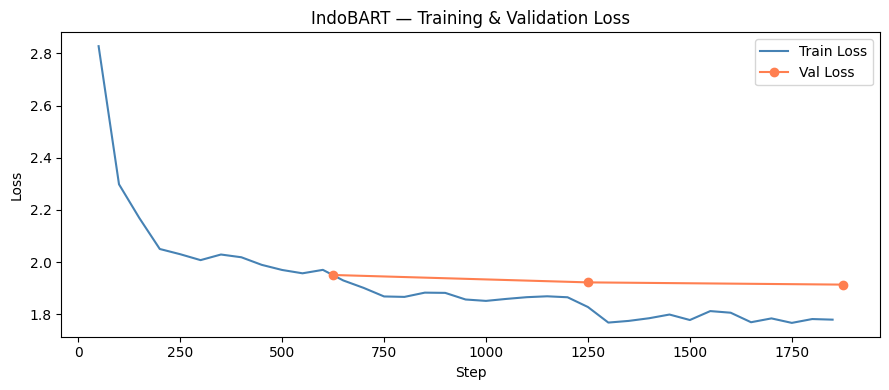

Final train loss : 1.7798
Final val loss   : 1.9141


In [15]:
if INDOBART_TRAINED:
    log        = indobart_trainer.state.log_history
    tr_steps   = [x["step"]      for x in log if "loss"      in x and "eval_loss" not in x]
    tr_losses  = [x["loss"]      for x in log if "loss"      in x and "eval_loss" not in x]
    val_steps  = [x["step"]      for x in log if "eval_loss" in x]
    val_losses = [x["eval_loss"] for x in log if "eval_loss" in x]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(tr_steps,  tr_losses,  color="steelblue", label="Train Loss")
    ax.plot(val_steps, val_losses, color="coral",     label="Val Loss", marker="o")
    ax.set_title("IndoBART — Training & Validation Loss")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
    if tr_losses:
        print(f"Final train loss : {tr_losses[-1]:.4f}")
    if val_losses:
        print(f"Final val loss   : {val_losses[-1]:.4f}")
    stopped = indobart_trainer.state.global_step
    total   = indobart_trainer.state.max_steps
    if stopped < total:
        print(f"Early stopping aktif: berhenti di step {stopped} dari {total}")
else:
    print("IndoBART tidak ditraining — skip loss curves.")

In [16]:
if INDOBART_TRAINED:
    free_vram(indobart_model, indobart_trainer, indobart_collator, indobart_tokenizer)
try:
    del ds_indobart_train, ds_indobart_val
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
if DEVICE == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"VRAM bebas setelah IndoBART: {free/1e9:.1f} GB / {total/1e9:.1f} GB")

VRAM bebas setelah IndoBART: 22.9 GB / 25.3 GB


# TRAINING mT5-Base

In [ ]:
# Konfigurasi mT5-base
MT5_CONFIG = {
    "num_train_epochs"            : SUMM_EPOCHS,           # 3 epoch, cukup untuk 10K data
    "per_device_train_batch_size" : SUMM_BATCH,            # 8 sampel per step per GPU
    "per_device_eval_batch_size"  : SUMM_EVAL_BATCH,       # 4 saat eval, lebih hemat VRAM
    "gradient_accumulation_steps" : SUMM_GRAD_ACCUM,       # eff. batch = 8 * 2 = 16
    "learning_rate"               : SUMM_LR,               # 5e-5, KRITIS untuk mT5
    "warmup_ratio"                : WARMUP_RATIO,          # 10% langkah pertama sebagai warmup
    "weight_decay"                : WEIGHT_DECAY,          # L2 regularisasi
    "max_grad_norm"               : SUMM_MAX_GRAD_NORM,    # gradient clipping 1.0
    "label_smoothing_factor"      : LABEL_SMOOTHING,       # 0.1, regularisasi output
    "bf16"                        : USE_BF16,              # True di RTX 30xx/40xx
    "fp16"                        : False,                 # JANGAN: NaN overflow di mT5
    "gradient_checkpointing"      : True,                  # recompute aktivasi, hemat VRAM
    "eval_accumulation_steps"     : EVAL_ACCUM_STEPS,      # cegah OOM saat evaluasi
    "early_stopping_patience"     : EARLY_STOP_PATIENCE,   # hentikan jika 2 epoch stagnan
}
print("mT5-base config:")
for k, v in MT5_CONFIG.items():
    print(f"  {k:35s}: {v}")
if DEVICE == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"\nVRAM bebas sebelum load: {free/1e9:.1f} GB / {total/1e9:.1f} GB")

mT5-base config:
  num_train_epochs                   : 3
  per_device_train_batch_size        : 8
  per_device_eval_batch_size         : 4
  gradient_accumulation_steps        : 2
  learning_rate                      : 5e-05
  warmup_ratio                       : 0.1
  weight_decay                       : 0.01
  max_grad_norm                      : 1.0
  label_smoothing_factor             : 0.1
  bf16                               : True
  fp16                               : False
  gradient_checkpointing             : True
  eval_accumulation_steps            : 4
  early_stopping_patience            : 2

VRAM bebas sebelum load: 22.9 GB / 25.3 GB


In [18]:
mt5_tokenizer = AutoTokenizer.from_pretrained(MT5BASE_MODEL)
mt5_model     = AutoModelForSeq2SeqLM.from_pretrained(MT5BASE_MODEL)
mt5_model.config.tie_word_embeddings = False  # silence tied-weight warning di mT5

ds_mt5_train = build_hf_dataset(df_train, mt5_tokenizer, "mt5")
ds_mt5_val   = build_hf_dataset(df_val,   mt5_tokenizer, "mt5")
mt5_collator = DataCollatorForSeq2Seq(
    mt5_tokenizer, model=mt5_model,
    padding="longest", label_pad_token_id=-100, return_tensors="pt",
)
print(f"Dataset tokenized  — train: {len(ds_mt5_train):,}  |  val: {len(ds_mt5_val):,}")

/venv/main/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/venv/main/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In prac

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/679 [00:00<?, ? examples/s]

Dataset tokenized  — train: 10,000  |  val: 679


In [19]:
MT5_TRAINED = False
try:
    mt5_args = Seq2SeqTrainingArguments(
        output_dir                  = str(MODELS_DIR / "mt5base"),
        num_train_epochs            = MT5_CONFIG["num_train_epochs"],
        per_device_train_batch_size = MT5_CONFIG["per_device_train_batch_size"],
        per_device_eval_batch_size  = MT5_CONFIG["per_device_eval_batch_size"],
        gradient_accumulation_steps = MT5_CONFIG["gradient_accumulation_steps"],
        learning_rate               = MT5_CONFIG["learning_rate"],
        warmup_ratio                = MT5_CONFIG["warmup_ratio"],
        weight_decay                = MT5_CONFIG["weight_decay"],
        max_grad_norm               = MT5_CONFIG["max_grad_norm"],
        label_smoothing_factor      = MT5_CONFIG["label_smoothing_factor"],
        bf16                        = MT5_CONFIG["bf16"],
        fp16                        = MT5_CONFIG["fp16"],
        gradient_checkpointing      = MT5_CONFIG["gradient_checkpointing"],
        eval_accumulation_steps     = MT5_CONFIG["eval_accumulation_steps"],
        predict_with_generate       = True,
        generation_max_length       = SUMM_MAX_TARGET,
        generation_num_beams        = 4,
        evaluation_strategy         = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "eval_loss",
        greater_is_better           = False,
        save_total_limit            = 2,
        logging_steps               = 50,
        report_to                   = "none",
        dataloader_pin_memory       = False,
        seed                        = RANDOM_SEED,
    )
    mt5_trainer = Seq2SeqTrainer(
        model         = mt5_model,
        args          = mt5_args,
        train_dataset = ds_mt5_train,
        eval_dataset  = ds_mt5_val,
        data_collator = mt5_collator,
        tokenizer     = mt5_tokenizer,
        callbacks     = [EarlyStoppingCallback(
            early_stopping_patience=MT5_CONFIG["early_stopping_patience"]
        )],
    )
    print(f"Mulai training mT5-base ({len(ds_mt5_train):,} data, {MT5_CONFIG['num_train_epochs']} epoch)...")
    mt5_trainer.train()
    mt5_trainer.save_model(str(MODELS_DIR / "mt5base"))
    mt5_tokenizer.save_pretrained(str(MODELS_DIR / "mt5base"))
    MT5_TRAINED = True
    print("mT5-base training selesai.")
except Exception as _e:
    print(f"[WARNING] mT5-base training gagal: {type(_e).__name__}: {_e}")
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

[RANK 0] Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
/venv/main/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Mulai training mT5-base (10,000 data, 3 epoch)...


Epoch,Training Loss,Validation Loss
1,2.594100,2.415352
2,2.420100,2.323707
3,2.421400,2.299796


/venv/main/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/venv/main/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
There were missing

mT5-base training selesai.


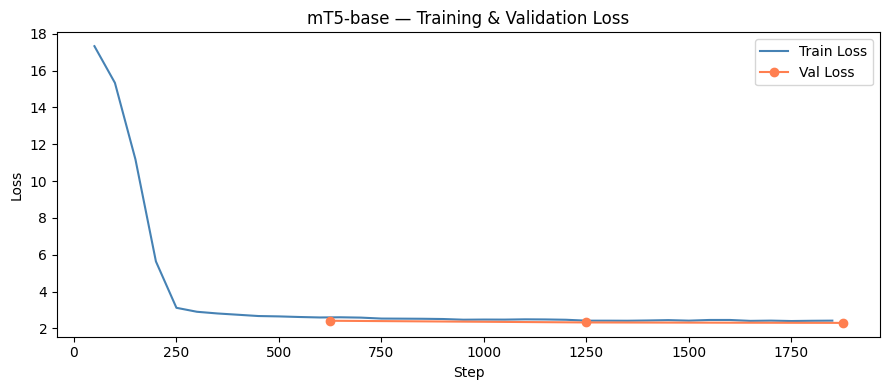

Final train loss : 2.4214
Final val loss   : 2.2998


In [20]:
if MT5_TRAINED:
    log        = mt5_trainer.state.log_history
    tr_steps   = [x["step"]      for x in log if "loss"      in x and "eval_loss" not in x]
    tr_losses  = [x["loss"]      for x in log if "loss"      in x and "eval_loss" not in x]
    val_steps  = [x["step"]      for x in log if "eval_loss" in x]
    val_losses = [x["eval_loss"] for x in log if "eval_loss" in x]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(tr_steps,  tr_losses,  color="steelblue", label="Train Loss")
    ax.plot(val_steps, val_losses, color="coral",     label="Val Loss", marker="o")
    ax.set_title("mT5-base — Training & Validation Loss")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
    if tr_losses:
        print(f"Final train loss : {tr_losses[-1]:.4f}")
    if val_losses:
        print(f"Final val loss   : {val_losses[-1]:.4f}")
    stopped = mt5_trainer.state.global_step
    total   = mt5_trainer.state.max_steps
    if stopped < total:
        print(f"Early stopping aktif: berhenti di step {stopped} dari {total}")
else:
    print("mT5-base tidak ditraining — skip loss curves.")

In [21]:
if MT5_TRAINED:
    free_vram(mt5_model, mt5_trainer, mt5_collator, mt5_tokenizer)
try:
    del ds_mt5_train, ds_mt5_val
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
if DEVICE == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"VRAM bebas setelah mT5-base: {free/1e9:.1f} GB / {total/1e9:.1f} GB")

VRAM bebas setelah mT5-base: 13.8 GB / 25.3 GB


# TRAIN INDOT5

In [ ]:
# Konfigurasi IndoT5
INDOT5_CONFIG = {
    "num_train_epochs"            : SUMM_EPOCHS,
    "per_device_train_batch_size" : SUMM_BATCH,
    "per_device_eval_batch_size"  : SUMM_EVAL_BATCH,
    "gradient_accumulation_steps" : SUMM_GRAD_ACCUM,
    "learning_rate"               : SUMM_LR,
    "warmup_ratio"                : WARMUP_RATIO,
    "weight_decay"                : WEIGHT_DECAY,
    "max_grad_norm"               : SUMM_MAX_GRAD_NORM,
    "label_smoothing_factor"      : LABEL_SMOOTHING,
    "bf16"                        : USE_BF16,
    "fp16"                        : False,
    "gradient_checkpointing"      : True,
    "eval_accumulation_steps"     : EVAL_ACCUM_STEPS,
    "early_stopping_patience"     : EARLY_STOP_PATIENCE,
}
print("IndoT5 config:")
for k, v in INDOT5_CONFIG.items():
    print(f"  {k:35s}: {v}")
if DEVICE == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"\nVRAM bebas sebelum load: {free/1e9:.1f} GB / {total/1e9:.1f} GB")


IndoT5 config:
  num_train_epochs                   : 3
  per_device_train_batch_size        : 8
  per_device_eval_batch_size         : 4
  gradient_accumulation_steps        : 2
  learning_rate                      : 5e-05
  warmup_ratio                       : 0.1
  weight_decay                       : 0.01
  max_grad_norm                      : 1.0
  label_smoothing_factor             : 0.1
  bf16                               : True
  fp16                               : False
  gradient_checkpointing             : True
  eval_accumulation_steps            : 4
  early_stopping_patience            : 2

VRAM bebas sebelum load: 13.8 GB / 25.3 GB


In [23]:
indot5_tokenizer = AutoTokenizer.from_pretrained(INDOT5_MODEL)
indot5_model     = AutoModelForSeq2SeqLM.from_pretrained(INDOT5_MODEL)

ds_indot5_train = build_hf_dataset(df_train, indot5_tokenizer, "t5")
ds_indot5_val   = build_hf_dataset(df_val,   indot5_tokenizer, "t5")
indot5_collator = DataCollatorForSeq2Seq(
    indot5_tokenizer, model=indot5_model,
    padding="longest", label_pad_token_id=-100, return_tensors="pt",
)
print(f"Dataset tokenized  — train: {len(ds_indot5_train):,}  |  val: {len(ds_indot5_val):,}")


/venv/main/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/657 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/793k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/679 [00:00<?, ? examples/s]

Dataset tokenized  — train: 10,000  |  val: 679


In [24]:
INDOT5_TRAINED = False
try:
    indot5_args = Seq2SeqTrainingArguments(
        output_dir                  = str(MODELS_DIR / "indot5"),
        num_train_epochs            = INDOT5_CONFIG["num_train_epochs"],
        per_device_train_batch_size = INDOT5_CONFIG["per_device_train_batch_size"],
        per_device_eval_batch_size  = INDOT5_CONFIG["per_device_eval_batch_size"],
        gradient_accumulation_steps = INDOT5_CONFIG["gradient_accumulation_steps"],
        learning_rate               = INDOT5_CONFIG["learning_rate"],
        warmup_ratio                = INDOT5_CONFIG["warmup_ratio"],
        weight_decay                = INDOT5_CONFIG["weight_decay"],
        max_grad_norm               = INDOT5_CONFIG["max_grad_norm"],
        label_smoothing_factor      = INDOT5_CONFIG["label_smoothing_factor"],
        bf16                        = INDOT5_CONFIG["bf16"],
        fp16                        = INDOT5_CONFIG["fp16"],
        gradient_checkpointing      = INDOT5_CONFIG["gradient_checkpointing"],
        eval_accumulation_steps     = INDOT5_CONFIG["eval_accumulation_steps"],
        predict_with_generate       = True,
        generation_max_length       = SUMM_MAX_TARGET,
        generation_num_beams        = 4,
        evaluation_strategy         = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "eval_loss",
        greater_is_better           = False,
        save_total_limit            = 2,
        logging_steps               = 50,
        report_to                   = "none",
        dataloader_pin_memory       = False,
        seed                        = RANDOM_SEED,
    )
    indot5_trainer = Seq2SeqTrainer(
        model         = indot5_model,
        args          = indot5_args,
        train_dataset = ds_indot5_train,
        eval_dataset  = ds_indot5_val,
        data_collator = indot5_collator,
        tokenizer     = indot5_tokenizer,
        callbacks     = [EarlyStoppingCallback(
            early_stopping_patience=INDOT5_CONFIG["early_stopping_patience"]
        )],
    )
    print(f"Mulai training IndoT5 ({len(ds_indot5_train):,} data, {INDOT5_CONFIG['num_train_epochs']} epoch)...")
    indot5_trainer.train()
    indot5_trainer.save_model(str(MODELS_DIR / "indot5"))
    indot5_tokenizer.save_pretrained(str(MODELS_DIR / "indot5"))
    INDOT5_TRAINED = True
    print("IndoT5 training selesai.")
except Exception as _e:
    print(f"[WARNING] IndoT5 training gagal: {type(_e).__name__}: {_e}")
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

[RANK 0] Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Mulai training IndoT5 (10,000 data, 3 epoch)...


/venv/main/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss
1,2.499000,2.359168
2,2.337300,2.297658
3,2.332800,2.281892


/venv/main/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/venv/main/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
There were missing

IndoT5 training selesai.


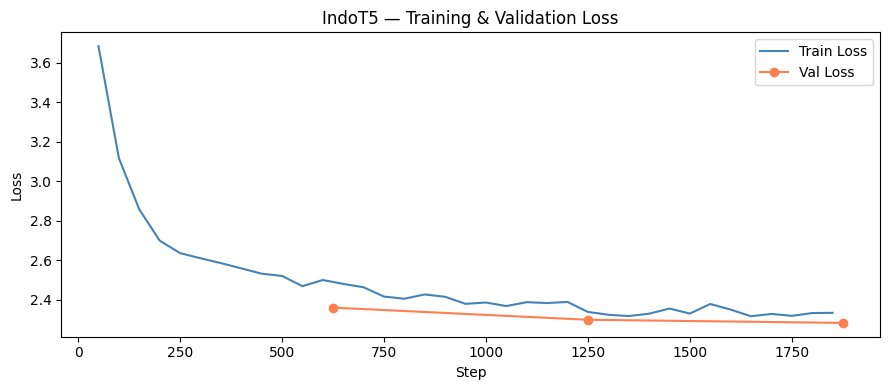

Final train loss : 2.3328
Final val loss   : 2.2819


In [25]:
if INDOT5_TRAINED:
    log        = indot5_trainer.state.log_history
    tr_steps   = [x["step"]      for x in log if "loss"      in x and "eval_loss" not in x]
    tr_losses  = [x["loss"]      for x in log if "loss"      in x and "eval_loss" not in x]
    val_steps  = [x["step"]      for x in log if "eval_loss" in x]
    val_losses = [x["eval_loss"] for x in log if "eval_loss" in x]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(tr_steps,  tr_losses,  color="steelblue", label="Train Loss")
    ax.plot(val_steps, val_losses, color="coral",     label="Val Loss", marker="o")
    ax.set_title("IndoT5 — Training & Validation Loss")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
    if tr_losses:
        print(f"Final train loss : {tr_losses[-1]:.4f}")
    if val_losses:
        print(f"Final val loss   : {val_losses[-1]:.4f}")
    stopped = indot5_trainer.state.global_step
    total   = indot5_trainer.state.max_steps
    if stopped < total:
        print(f"Early stopping aktif: berhenti di step {stopped} dari {total}")
else:
    print("IndoT5 tidak ditraining — skip loss curves.")


In [26]:
if INDOT5_TRAINED:
    free_vram(indot5_model, indot5_trainer, indot5_collator, indot5_tokenizer)
del ds_indot5_train, ds_indot5_val
gc.collect()
torch.cuda.empty_cache()
if DEVICE == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"VRAM bebas setelah IndoT5: {free/1e9:.1f} GB / {total/1e9:.1f} GB")


VRAM bebas setelah IndoT5: 12.5 GB / 25.3 GB


# Extractive baseline: TextRank & NER

In [49]:
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


def split_sentences(text: str) -> list:
    sents = re.split(r"(?<=[.!?])\s+", text.strip())
    return [s.strip() for s in sents if s.strip()]


def summarize_textrank(text: str, n_sentences: int = 3, max_words: int = 80) -> str:
    raw_sents  = split_sentences(text)                         # untuk output
    stem_sents = split_sentences(preprocess_extractive(text))  # untuk TF-IDF similarity
    if len(raw_sents) <= n_sentences:
        result = " ".join(raw_sents)
    else:
        try:
            vec    = TfidfVectorizer().fit_transform(stem_sents)
            sim    = cosine_similarity(vec)
            np.fill_diagonal(sim, 0)
            g      = nx.from_numpy_array(sim)
            scores = nx.pagerank(g, max_iter=200)
            ranked = sorted(range(len(raw_sents)), key=lambda i: scores[i], reverse=True)
            result = " ".join(raw_sents[i] for i in sorted(ranked[:n_sentences]))
        except Exception:
            result = " ".join(raw_sents[:n_sentences])
    words = result.split()
    if len(words) > max_words:
        result = " ".join(words[:max_words])
    return result

In [50]:
_sample_text = df_train.iloc[0]["text"]
tr_out = summarize_textrank(_sample_text, n_sentences=3, max_words=80)
print(f"TextRank sanity check:")
print(f"  input length : {len(_sample_text.split())} words")
print(f"  output length: {len(tr_out.split())} words  (max_words=80 hard cap)")
print(f"  output: {tr_out[:150]}...")


TextRank sanity check:
  input length : 334 words
  output length: 57 words  (max_words=80 hard cap)
  output: Pelatih AC Milan Vincenzo Montella mengatakan klubnya tidak sedang dikejar waktu untuk segera merekrut penyerang baru demi menambah kualitas skuatnya....


In [29]:
def summarize_ner(text: str, n_sentences: int = 3, max_words: int = 80) -> str:
    # Pilih kalimat dengan density kata berkapital terbanyak (proxy named entities)
    raw_sents = split_sentences(text)
    if not raw_sents:
        return ""

    def entity_density(s: str) -> float:
        words = s.split()
        if not words:
            return 0.0
        caps = sum(1 for w in words[1:] if w and w[0].isupper())
        return caps / len(words)

    scores = [(i, entity_density(s)) for i, s in enumerate(raw_sents)]
    ranked = sorted(scores, key=lambda x: x[1], reverse=True)[:n_sentences]
    result = " ".join(raw_sents[i] for i, _ in sorted(ranked))
    words  = result.split()
    if len(words) > max_words:
        result = " ".join(words[:max_words])
    return result


In [30]:
ner_out = summarize_ner(_sample_text, n_sentences=3, max_words=80)
print(f"NER sanity check:")
print(f"  input length : {len(_sample_text.split())} words")
print(f"  output length: {len(ner_out.split())} words")
print(f"  output: {ner_out[:150]}...")


NER sanity check:
  input length : 334 words
  output length: 80 words
  output: Sejauh ini Milan telah merekrut sepuluh pemain termasuk penyerang asal Portugal Andre Silva dan bek Juventus Leonardo Bonucci dalam bursa transfer yan...


# Evaluasi Seluruh Model

In [ ]:
from rouge_score import rouge_scorer as rouge_lib
from tqdm.auto import tqdm


def load_model_for_eval(output_dir: str):
    # Cek tokenizer_info.json — ditulis saat IndoNLGTokenizer.save_pretrained() gagal
    # (NotImplementedError). Jika ada, reload tokenizer dari original HF model.
    info_path = Path(output_dir) / "tokenizer_info.json"
    tok_source = output_dir
    if info_path.exists():
        _info = json.loads(info_path.read_text())
        tok_source = _info.get("original_model", output_dir)
        print(f"  Tokenizer fallback: load dari {tok_source}")
    try:
        from indobenchmark import IndoNLGTokenizer
        tokenizer = IndoNLGTokenizer.from_pretrained(tok_source)
    except Exception:
        tokenizer = AutoTokenizer.from_pretrained(tok_source)
    model = AutoModelForSeq2SeqLM.from_pretrained(output_dir)
    model.eval()
    model.to(DEVICE)
    return model, tokenizer


def _decode_sequences(tokenizer, sequences):
    # IndoNLGTokenizer.decode() tidak support kwarg clean_up_tokenization_spaces
    # yang di-inject oleh batch_decode. Panggil decode() per-sequence secara langsung.
    return [
        tokenizer.decode(seq.tolist(), skip_special_tokens=True)
        for seq in sequences
    ]


def evaluate_neural(model, tokenizer, model_type, df, demo_texts=None, batch_size=8):
    scorer     = rouge_lib.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)
    sums       = {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
    cr_total   = 0.0
    orig_texts = df["text"].tolist()
    summaries  = df["summary"].astype(str).tolist()

    texts = [preprocess_abstractive(t) for t in orig_texts]
    if model_type == "mt5":
        texts = ["summarize: " + t for t in texts]

    n_batches = (len(texts) + batch_size - 1) // batch_size
    preds     = []
    for i in tqdm(range(0, len(texts), batch_size), total=n_batches,
                  desc="Generating", unit="batch"):
        batch = texts[i : i + batch_size]
        enc   = tokenizer(
            batch, return_tensors="pt", truncation=True,
            max_length=SUMM_MAX_INPUT, padding=True,
        ).to(DEVICE)
        with torch.no_grad():
            out = model.generate(**enc, **GEN_KWARGS)
        preds.extend(_decode_sequences(tokenizer, out))

    for pred, ref, orig in zip(preds, summaries, orig_texts):
        sc = scorer.score(ref, pred)
        for k in sums:
            sums[k] += sc[k].fmeasure
        cr_total += len(ref.split()) / max(len(orig.split()), 1)

    n       = len(df)
    metrics = {k: round(v / n, 4) for k, v in sums.items()}
    metrics["CR"] = round(cr_total / n, 4)

    demo_preds = []
    if demo_texts:
        for text in demo_texts:
            t = preprocess_abstractive(text)
            if model_type == "mt5":
                t = "summarize: " + t
            enc = tokenizer(t, return_tensors="pt",
                            truncation=True, max_length=SUMM_MAX_INPUT).to(DEVICE)
            with torch.no_grad():
                out = model.generate(**enc, **GEN_KWARGS)
            demo_preds.append(tokenizer.decode(out[0].tolist(), skip_special_tokens=True))

    return metrics, demo_preds


# Text demo — dibuat manual, BUKAN dari test set (no data leakage)
SAMPLE_TEXTS = [
    (
        "Olahraga",
        "Timnas Indonesia meraih kemenangan 2-1 atas Vietnam dalam laga kualifikasi "
        "Piala Dunia 2026 zona Asia yang berlangsung di Stadion Gelora Bung Karno. "
        "Gol pertama dicetak Rafael Struick melalui sundulan kepala di menit ke-23. "
        "Vietnam menyamakan kedudukan di menit ke-58 lewat tendangan bebas kapten mereka. "
        "Namun Indonesia membalas lewat gol Witan Sulaeman di menit ke-87. "
        "Kemenangan ini mengangkat Indonesia ke posisi kedua klasemen sementara. "
        "Pelatih Shin Tae-yong menyatakan timnya akan terus bekerja keras untuk lolos."
    ),
    (
        "Pengaduan",
        "Warga RT 07 RW 03 Kelurahan Cengkareng Timur mengeluhkan kondisi jalan berlubang "
        "yang sudah berlangsung lebih dari tiga bulan tanpa penanganan dari pemerintah. "
        "Kerusakan jalan sepanjang 200 meter itu membahayakan pengendara terutama malam hari. "
        "Beberapa sepeda motor sudah mengalami kecelakaan akibat menghantam lubang besar. "
        "Warga sudah dua kali melaporkan ke kelurahan namun belum ada tindak lanjut. "
        "Selain jalan berlubang, drainase juga tersumbat sehingga saat hujan air meluap. "
        "Warga meminta pemerintah Kota Jakarta Barat segera memperbaiki sebelum ada korban."
    ),
]

print(f"Evaluasi akan dijalankan pada df_test ({len(df_test):,} rows)")
print(f"Demo: {len(SAMPLE_TEXTS)} teks buatan sendiri")

Evaluasi akan dijalankan pada df_test (700 rows)
Demo: 2 teks buatan sendiri


In [41]:
demo_raw_texts = [t for _, t in SAMPLE_TEXTS]

mt5_metrics, mt5_demo = {"rouge1": 0, "rouge2": 0, "rougeL": 0, "CR": 0}, []
if MT5_TRAINED:
    print("Evaluasi mT5-base pada test set...")
    _model, _tok = load_model_for_eval(str(MODELS_DIR / "mt5base"))
    mt5_metrics, mt5_demo = evaluate_neural(_model, _tok, "mt5", df_test, demo_raw_texts)
    free_vram(_model, _tok)
    print(f"  mT5-base : {mt5_metrics}")
else:
    print("[SKIP] mT5-base tidak ditraining.")


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'T5Tokenizer'. 
The class this function is called from is 'IndoNLGTokenizer'.


Evaluasi mT5-base pada test set...


/venv/main/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Generating:   0%|          | 0/88 [00:00<?, ?batch/s]

  mT5-base : {'rouge1': 0.7043, 'rouge2': 0.6224, 'rougeL': 0.6719, 'CR': 0.2279}


In [42]:
indobart_metrics, indobart_demo = {"rouge1": 0, "rouge2": 0, "rougeL": 0, "CR": 0}, []
if INDOBART_TRAINED:
    print("Evaluasi IndoBART pada test set...")
    _model, _tok = load_model_for_eval(str(MODELS_DIR / "indobart"))
    indobart_metrics, indobart_demo = evaluate_neural(_model, _tok, "bart", df_test, demo_raw_texts)
    free_vram(_model, _tok)
    print(f"  IndoBART : {indobart_metrics}")
else:
    print("[SKIP] IndoBART tidak ditraining.")


Evaluasi IndoBART pada test set...
  Tokenizer fallback: load dari indobenchmark/indoBART


/venv/main/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Generating:   0%|          | 0/88 [00:00<?, ?batch/s]

/venv/main/lib/python3.12/site-packages/transformers/generation/utils.py:1256: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed soon, in a future version. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


  IndoBART : {'rouge1': 0.5676, 'rouge2': 0.4884, 'rougeL': 0.5282, 'CR': 0.2279}


In [43]:
indot5_metrics, indot5_demo = {"rouge1": 0, "rouge2": 0, "rougeL": 0, "CR": 0}, []
if INDOT5_TRAINED:
    print("Evaluasi IndoT5 pada test set...")
    _model, _tok = load_model_for_eval(str(MODELS_DIR / "indot5"))
    indot5_metrics, indot5_demo = evaluate_neural(_model, _tok, "t5", df_test, demo_raw_texts)
    free_vram(_model, _tok)
    print(f"  IndoT5   : {indot5_metrics}")
else:
    print("[SKIP] IndoT5 tidak ditraining.")


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'T5Tokenizer'. 
The class this function is called from is 'IndoNLGTokenizer'.


Evaluasi IndoT5 pada test set...


Generating:   0%|          | 0/88 [00:00<?, ?batch/s]

  IndoT5   : {'rouge1': 0.6977, 'rouge2': 0.6114, 'rougeL': 0.6674, 'CR': 0.2279}


In [51]:
def evaluate_extractive(fn, df):
    scorer   = rouge_lib.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)
    sums     = {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
    cr_total = 0.0
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Evaluating", unit="sample"):
        pred = fn(row["text"])
        sc   = scorer.score(row["summary"], pred)
        for k in sums:
            sums[k] += sc[k].fmeasure
        cr_total += len(pred.split()) / max(len(row["text"].split()), 1)
    n = len(df)
    m = {k: round(v / n, 4) for k, v in sums.items()}
    m["CR"] = round(cr_total / n, 4)
    return m

print("Evaluasi TextRank pada test set...")
textrank_metrics = evaluate_extractive(summarize_textrank, df_test)
print(f"  TextRank : {textrank_metrics}")

print("Evaluasi NER pada test set...")
ner_metrics = evaluate_extractive(summarize_ner, df_test)
print(f"  NER      : {ner_metrics}")

textrank_demo = [summarize_textrank(t) for _, t in SAMPLE_TEXTS]
ner_demo      = [summarize_ner(t) for _, t in SAMPLE_TEXTS]

Evaluasi TextRank pada test set...


Evaluating:   0%|          | 0/700 [00:00<?, ?sample/s]

  TextRank : {'rouge1': 0.6688, 'rouge2': 0.6003, 'rougeL': 0.639, 'CR': 0.225}
Evaluasi NER pada test set...


Evaluating:   0%|          | 0/700 [00:00<?, ?sample/s]

  NER      : {'rouge1': 0.4272, 'rouge2': 0.3192, 'rougeL': 0.3788, 'CR': 0.2193}


In [52]:
results = {
    "TextRank" : textrank_metrics,
    "NER"      : ner_metrics,
    "IndoT5"   : indot5_metrics,
    "IndoBART" : indobart_metrics,
    "mT5-base" : mt5_metrics,
}

results_df = pd.DataFrame(results).T.rename(columns={
    "rouge1": "ROUGE-1", "rouge2": "ROUGE-2", "rougeL": "ROUGE-L", "CR": "Comp. Ratio"
})
results_df.index.name = "Method"
print("\nHasil evaluasi pada test set (n=700):")
display(results_df.style.highlight_max(axis=0, color="lightgreen").format("{:.4f}"))



Hasil evaluasi pada test set (n=700):


,ROUGE-1,ROUGE-2,ROUGE-L,Comp. Ratio
Method,,,,
TextRank,0.6688,0.6003,0.6390,0.2250
NER,0.4272,0.3192,0.3788,0.2193
IndoT5,0.6977,0.6114,0.6674,0.2279
IndoBART,0.5676,0.4884,0.5282,0.2279
mT5-base,0.7043,0.6224,0.6719,0.2279


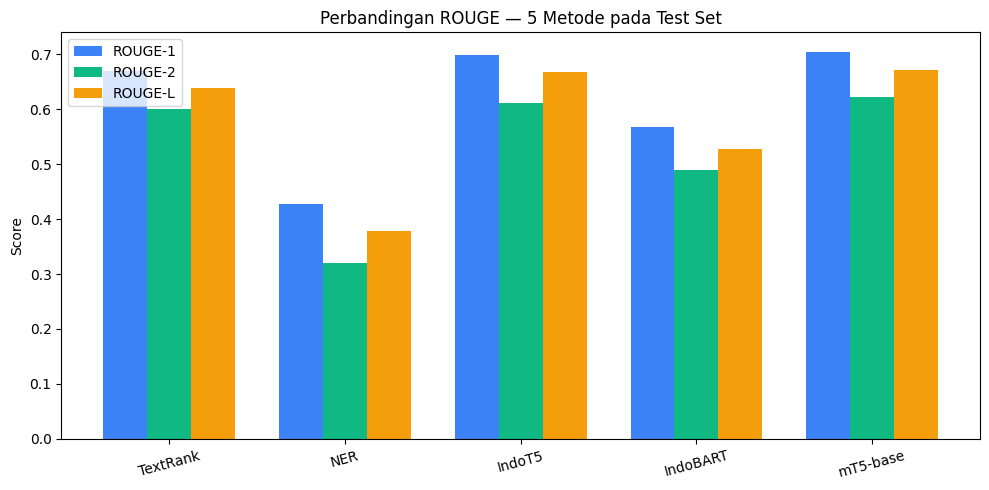

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))
methods = list(results.keys())
r1 = [results[m]["rouge1"] for m in methods]
r2 = [results[m]["rouge2"] for m in methods]
rl = [results[m]["rougeL"] for m in methods]

x = np.arange(len(methods))
w = 0.25
ax.bar(x - w, r1, w, label="ROUGE-1", color="#3b82f6")
ax.bar(x,     r2, w, label="ROUGE-2", color="#10b981")
ax.bar(x + w, rl, w, label="ROUGE-L", color="#f59e0b")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15)
ax.set_ylabel("Score")
ax.set_title("Perbandingan ROUGE — 5 Metode pada Test Set")
ax.legend()
plt.tight_layout()
plt.show()


## 12. Demo — perbandingan output 5 metode

Teks input adalah teks buatan sendiri (bukan dari test set) untuk memastikan tidak ada informasi yang bocor dari test set.

In [54]:
demo_outputs = {
    "TextRank" : textrank_demo,
    "NER"      : ner_demo,
    "IndoT5"   : indot5_demo,
    "IndoBART" : indobart_demo,
    "mT5-base" : mt5_demo,
}

for idx, (category, raw_text) in enumerate(SAMPLE_TEXTS):
    print(f"{"="*65}")
    print(f"Sample {idx+1}  [Kategori: {category}]")
    print(f"INPUT ({len(raw_text.split())} words): {raw_text[:120]}...")
    print(f"{"="*65}")
    for method, preds in demo_outputs.items():
        pred = preds[idx] if preds and idx < len(preds) else "[tidak tersedia]"
        print(f"  {method:10s}: {pred}")
        print(f"{"-"*65}")
    print()


Sample 1  [Kategori: Olahraga]
INPUT (74 words): Timnas Indonesia meraih kemenangan 2-1 atas Vietnam dalam laga kualifikasi Piala Dunia 2026 zona Asia yang berlangsung d...
  TextRank  : Timnas Indonesia meraih kemenangan 2-1 atas Vietnam dalam laga kualifikasi Piala Dunia 2026 zona Asia yang berlangsung di Stadion Gelora Bung Karno. Gol pertama dicetak Rafael Struick melalui sundulan kepala di menit ke-23. Vietnam menyamakan kedudukan di menit ke-58 lewat tendangan bebas kapten mereka.
-----------------------------------------------------------------
  NER       : Timnas Indonesia meraih kemenangan 2-1 atas Vietnam dalam laga kualifikasi Piala Dunia 2026 zona Asia yang berlangsung di Stadion Gelora Bung Karno. Gol pertama dicetak Rafael Struick melalui sundulan kepala di menit ke-23. Namun Indonesia membalas lewat gol Witan Sulaeman di menit ke-87.
-----------------------------------------------------------------
  IndoT5    : Timnas Indonesia meraih kemenangan 2-1 atas Vietnam dalam 

Output important from this pipeline:
- `models/mt5base/` — mT5-base fine-tuned + tokenizer + config
- `models/indobart/` — IndoBART fine-tuned + tokenizer + config
- `models/indot5/` — IndoT5 fine-tuned + tokenizer + config